## Question 10


In [2]:
import numpy as np

# Monthly closing prices
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])

# --------------------------------------------------
# (a) Monthly simple returns
# --------------------------------------------------
# Return_t = (P_t - P_(t-1)) / P_(t-1)

returns = prices[:, 1:] / prices[:, :-1] - 1

print("Monthly Returns (shape =", returns.shape, "):")
print(returns)

# --------------------------------------------------
# (b) Annualised mean return and annualised volatility
# --------------------------------------------------

monthly_mean = np.mean(returns, axis=1)
monthly_std = np.std(returns, axis=1, ddof=1)   # sample standard deviation

annual_mean = 12 * monthly_mean
annual_std = np.sqrt(12) * monthly_std

print("\nMonthly Mean Returns:")
print(monthly_mean)

print("\nAnnualised Mean Returns:")
print(annual_mean)

print("\nMonthly Standard Deviations:")
print(monthly_std)

print("\nAnnualised Standard Deviations:")
print(annual_std)

# --------------------------------------------------
# (c) Sample covariance matrix
# --------------------------------------------------

cov_matrix = np.cov(returns)

print("\nCovariance Matrix:")
print(cov_matrix)

# Correlation matrix
corr_matrix = np.corrcoef(returns)

print("\nCorrelation Matrix:")
print(corr_matrix)

# Verify covariance formula:
# Cov(A,B) = rho * sigma_A * sigma_B

rho = corr_matrix[0, 1]
sigma_A = np.std(returns[0], ddof=1)
sigma_B = np.std(returns[1], ddof=1)

cov_from_formula = rho * sigma_A * sigma_B

print("\nOff-diagonal covariance from matrix:")
print(cov_matrix[0, 1])

print("\nrho * sigma_A * sigma_B:")
print(cov_from_formula)

print("\nDifference:")
print(abs(cov_matrix[0, 1] - cov_from_formula))
print("\nThe values should be very close, confirming the relationship between covariance, correlation, and standard deviations.")

Monthly Returns (shape = (2, 11) ):
[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]

Monthly Mean Returns:
[0.03257282 0.01672819]

Annualised Mean Returns:
[0.39087388 0.20073826]

Monthly Standard Deviations:
[0.05831065 0.04209467]

Annualised Standard Deviations:
[0.20199403 0.14582022]

Covariance Matrix:
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]

Correlation Matrix:
[[ 1.         -0.84098736]
 [-0.84098736  1.        ]]

Off-diagonal covariance from matrix:
-0.0020642605060094284

rho * sigma_A * sigma_B:
-0.0020642605060094284

Difference:
0.0

The values should be very close, confirming the relationship between covariance, correlation, and standard deviations.


## Question 11

In [3]:
import numpy as np

# --------------------------------------------------
# Asset parameters
# --------------------------------------------------

mu = np.array([0.15, 0.08, 0.05])

sigma = np.array([0.25, 0.12, 0.04])

corr = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

# Covariance matrix
Sigma = np.outer(sigma, sigma) * corr

print("Covariance matrix:")
print(Sigma)

# --------------------------------------------------
# (a) Equal-weight portfolio
# --------------------------------------------------

w = np.array([1/3, 1/3, 1/3])

ER_p = w @ mu
var_p = w @ Sigma @ w
sd_p = np.sqrt(var_p)

print("\nEqual-weight portfolio")
print("Expected return =", ER_p)
print("Variance =", var_p)
print("Standard deviation =", sd_p)

# --------------------------------------------------
# (b) Generate 10,000 random portfolios
# --------------------------------------------------

np.random.seed(42)

n_portfolios = 10000

weights = np.random.dirichlet(
    np.ones(3),
    size=n_portfolios
)

# Portfolio expected returns
portfolio_returns = weights @ mu

# Portfolio variances
portfolio_variances = np.einsum(
    'ij,jk,ik->i',
    weights,
    Sigma,
    weights
)

portfolio_std = np.sqrt(portfolio_variances)

print("\nReturn array shape:", portfolio_returns.shape)
print("Risk array shape:", portfolio_std.shape)

# --------------------------------------------------
# (c) Sharpe ratios
# --------------------------------------------------

rf = 0.03

sharpe_ratios = (portfolio_returns - rf) / portfolio_std

max_idx = np.argmax(sharpe_ratios)

print("\nMaximum Sharpe Ratio =", sharpe_ratios[max_idx])
print("Optimal weights =", weights[max_idx])
print("Expected return =", portfolio_returns[max_idx])
print("Standard deviation =", portfolio_std[max_idx])

Covariance matrix:
[[0.0625  0.012   0.001  ]
 [0.012   0.0144  0.00096]
 [0.001   0.00096 0.0016 ]]

Equal-weight portfolio
Expected return = 0.09333333333333332
Variance = 0.011824444444444443
Standard deviation = 0.10874026137748816

Return array shape: (10000,)
Risk array shape: (10000,)

Maximum Sharpe Ratio = 0.6818604907959626
Optimal weights = [0.1032299  0.11623399 0.7805361 ]
Expected return = 0.06381001018814911
Standard deviation = 0.049584938040157386



## Question 12

In [4]:
import numpy as np

# --------------------------------------------------
# Parameters
# --------------------------------------------------

mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.60
w2 = 1 - w1

# --------------------------------------------------
# (a) Compute portfolio volatility for 200 rho values
# --------------------------------------------------

rho = np.linspace(-1, 1, 200)

# Portfolio variance:
# σp² = w1²σ1² + w2²σ2² + 2w1w2ρσ1σ2

portfolio_variance = (
    (w1**2) * (sigma1**2)
    + (w2**2) * (sigma2**2)
    + 2 * w1 * w2 * rho * sigma1 * sigma2
)

portfolio_std = np.sqrt(portfolio_variance)

print("Shape:", portfolio_std.shape)
print(portfolio_std)

# --------------------------------------------------
# (b) Minimum volatility and corresponding rho
# --------------------------------------------------

idx = np.argmin(portfolio_std)

rho_min = rho[idx]
sigma_min = portfolio_std[idx]

print("\nMinimum volatility =", sigma_min)
print("Occurs at rho =", rho_min)

# --------------------------------------------------
# Exact value at rho = -1
# --------------------------------------------------

var_exact = (
    (w1**2) * (sigma1**2)
    + (w2**2) * (sigma2**2)
    - 2 * w1 * w2 * sigma1 * sigma2
)

sigma_exact = np.sqrt(var_exact)

print("\nExact volatility at rho = -1 =", sigma_exact)

Shape: (200,)
[0.08       0.08060076 0.08119707 0.08178904 0.08237675 0.0829603
 0.08353978 0.08411526 0.08468683 0.08525457 0.08581855 0.08637885
 0.08693554 0.08748869 0.08803837 0.08858463 0.08912754 0.08966717
 0.09020357 0.09073679 0.09126691 0.09179396 0.092318   0.09283908
 0.09335726 0.09387257 0.09438508 0.09489481 0.09540182 0.09590615
 0.09640784 0.09690694 0.09740348 0.0978975  0.09838903 0.09887813
 0.09936482 0.09984913 0.10033111 0.10081078 0.10128819 0.10176335
 0.1022363  0.10270708 0.10317571 0.10364221 0.10410663 0.10456899
 0.10502931 0.10548762 0.10594395 0.10639832 0.10685076 0.10730129
 0.10774994 0.10819673 0.10864168 0.10908482 0.10952616 0.10996573
 0.11040355 0.11083965 0.11127403 0.11170672 0.11213775 0.11256712
 0.11299486 0.11342099 0.11384553 0.11426848 0.11468988 0.11510974
 0.11552806 0.11594488 0.11636021 0.11677406 0.11718645 0.11759739
 0.1180069  0.11841499 0.11882169 0.11922699 0.11963092 0.1200335
 0.12043472 0.12083462 0.12123319 0.12163046 0.122

## Question 13

In [5]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# Simulate weekly prices
# --------------------------------------------------

np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(
    mu_weekly,
    sig_weekly,
    (52, 4)
)

prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

print("Price DataFrame:")
print(df.head())

# --------------------------------------------------
# (a) Weekly simple returns
# --------------------------------------------------

weekly_returns = df.pct_change().dropna()

print("\nFirst 3 rows of weekly returns:")
print(weekly_returns.head(3))

print("\nShape of returns DataFrame:")
print(weekly_returns.shape)

# --------------------------------------------------
# (b) Descriptive statistics
# --------------------------------------------------

desc = weekly_returns.describe()

print("\nDescriptive Statistics:")
print(desc)

# Asset with highest mean return
highest_mean_asset = weekly_returns.mean().idxmax()

# Asset with highest standard deviation
highest_std_asset = weekly_returns.std().idxmax()

print("\nAsset with highest mean return:")
print(highest_mean_asset)

print("\nAsset with highest standard deviation:")
print(highest_std_asset)

# --------------------------------------------------
# (c) Annualised Sharpe Ratios
# --------------------------------------------------

rf_annual = 0.02

# Convert annual risk-free rate to weekly
rf_weekly = rf_annual / 52

mean_weekly = weekly_returns.mean()
std_weekly = weekly_returns.std()

annual_return = mean_weekly * 52
annual_vol = std_weekly * np.sqrt(52)

sharpe_ratio = (annual_return - rf_annual) / annual_vol

print("\nAnnualised Sharpe Ratios:")
print(sharpe_ratio)

Price DataFrame:
                  AAPL        MSFT       GOOGL        AMZN
2023-01-02  107.356209  101.400472  102.057476  105.752233
2023-01-09  115.698036   98.630379  104.098806  105.510702
2023-01-16  115.567441  100.042565  104.502800  109.505004
2023-01-23  119.432191  100.607830  105.535002  110.582737
2023-01-30  126.928133  100.189830  106.301329  108.387405

First 3 rows of weekly returns:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Shape of returns DataFrame:
(51, 4)

Descriptive Statistics:
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -

## Question 14

In [6]:
import pandas as pd
import numpy as np

# (a)
corr_matrix = weekly_returns.corr()
print(corr_matrix)

corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

print("Lowest correlation pair:",
      corr_pairs.stack().idxmin())

print("Lowest correlation value:",
      corr_pairs.stack().min())

# (b)
weights = pd.Series(
    [0.25, 0.25, 0.25, 0.25],
    index=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

portfolio_returns = weekly_returns.dot(weights)

# (c)
monthly_returns = portfolio_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)

print("\nMonthly returns:")
print(monthly_returns)

print("\nMean monthly return:")
print(monthly_returns.mean())

print("\nMonthly standard deviation:")
print(monthly_returns.std())

           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000
Lowest correlation pair: ('AAPL', 'MSFT')
Lowest correlation value: -0.07532396170747635

Monthly returns:
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.084694
2023-08-31    0.012007
2023-09-30    0.008753
2023-10-31    0.021548
2023-11-30   -0.049706
2023-12-31    0.026272
Freq: ME, dtype: float64

Mean monthly return:
0.013974973306651484

Monthly standard deviation:
0.039023369077949295


## Question 15

Maximum Sharpe Ratio: 0.6818604907959626
Weights: [0.1032299  0.11623399 0.7805361 ]


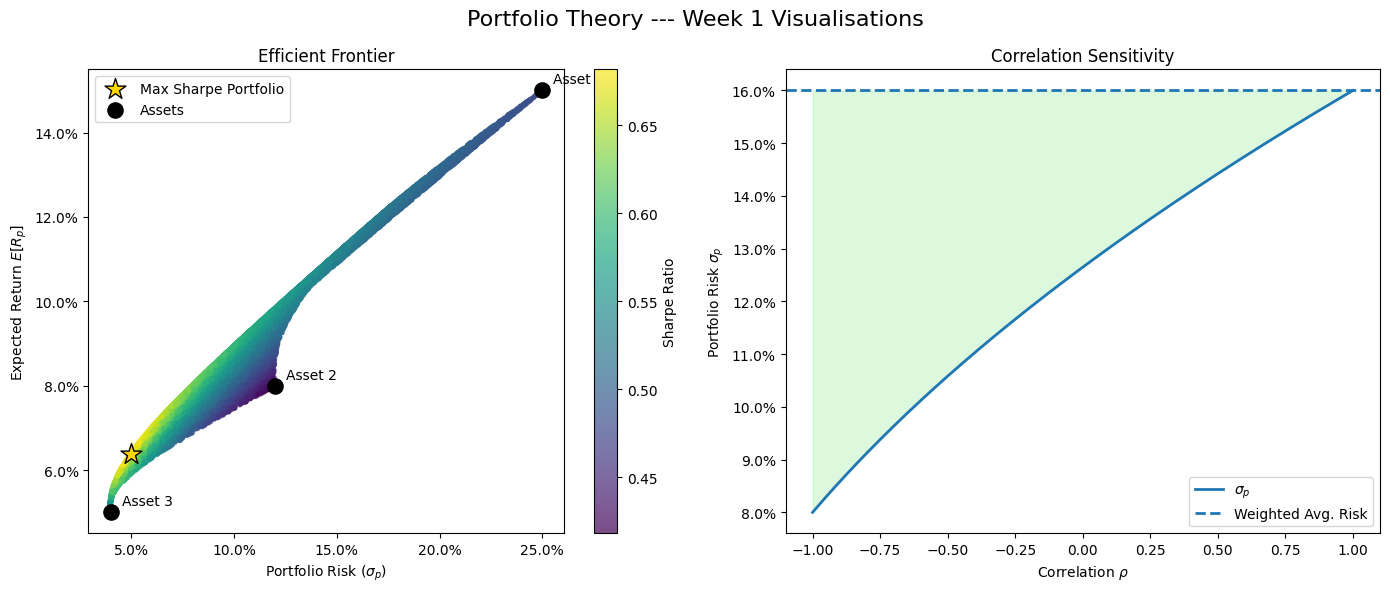

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ==================================================
# PART 1: 3-Asset Efficient Frontier
# ==================================================

# Asset parameters from Question 6

mu = np.array([0.15, 0.08, 0.05])

sigma = np.array([0.25, 0.12, 0.04])

corr = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

tickers = ['Asset 1', 'Asset 2', 'Asset 3']

# Covariance matrix
Sigma = np.outer(sigma, sigma) * corr

# --------------------------------------------------
# Simulate 20,000 random portfolios
# --------------------------------------------------

np.random.seed(42)

n_portfolios = 20000

weights = np.random.dirichlet(
    np.ones(3),
    size=n_portfolios
)

# Portfolio returns

portfolio_returns = weights @ mu

# Portfolio variances

portfolio_variances = np.einsum(
    'ij,jk,ik->i',
    weights,
    Sigma,
    weights
)

portfolio_risk = np.sqrt(portfolio_variances)

# Sharpe ratios

rf = 0.03

sharpe_ratios = (
    portfolio_returns - rf
) / portfolio_risk

# Maximum Sharpe portfolio

max_idx = np.argmax(sharpe_ratios)

max_return = portfolio_returns[max_idx]
max_risk = portfolio_risk[max_idx]
max_sharpe = sharpe_ratios[max_idx]
max_weights = weights[max_idx]

print("Maximum Sharpe Ratio:", max_sharpe)
print("Weights:", max_weights)

# ==================================================
# PART 2: Correlation Sensitivity
# ==================================================

mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.60
w2 = 0.40

rho = np.linspace(-1, 1, 200)

portfolio_variance_rho = (
    (w1**2) * sigma1**2
    + (w2**2) * sigma2**2
    + 2 * w1 * w2 * rho * sigma1 * sigma2
)

portfolio_std_rho = np.sqrt(portfolio_variance_rho)

weighted_avg_risk = (
    w1 * sigma1
    + w2 * sigma2
)

# ==================================================
# FIGURE
# ==================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# ==================================================
# LEFT PANEL:
# Efficient Frontier
# ==================================================

ax1 = axes[0]

scatter = ax1.scatter(
    portfolio_risk,
    portfolio_returns,
    c=sharpe_ratios,
    cmap='viridis',
    s=8,
    alpha=0.7
)

# Maximum Sharpe portfolio

ax1.scatter(
    max_risk,
    max_return,
    marker='*',
    s=250,
    color='gold',
    edgecolor='black',
    label='Max Sharpe Portfolio'
)

# Individual assets

ax1.scatter(
    sigma,
    mu,
    color='black',
    s=120,
    zorder=5,
    label='Assets'
)

for x, y, label in zip(sigma, mu, tickers):
    ax1.annotate(
        label,
        (x, y),
        xytext=(8, 5),
        textcoords='offset points'
    )

ax1.set_title('Efficient Frontier')

ax1.set_xlabel('Portfolio Risk ($\\sigma_p$)')
ax1.set_ylabel('Expected Return $E[R_p]$')

ax1.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax1.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

cbar = fig.colorbar(
    scatter,
    ax=ax1
)

cbar.set_label('Sharpe Ratio')

ax1.legend()

# ==================================================
# RIGHT PANEL:
# Correlation Sensitivity
# ==================================================

ax2 = axes[1]

ax2.plot(
    rho,
    portfolio_std_rho,
    linewidth=2,
    label=r'$\sigma_p$'
)

# Weighted average risk line

ax2.axhline(
    weighted_avg_risk,
    linestyle='--',
    linewidth=2,
    label='Weighted Avg. Risk'
)

# Diversification region

ax2.fill_between(
    rho,
    portfolio_std_rho,
    weighted_avg_risk,
    where=(portfolio_std_rho < weighted_avg_risk),
    alpha=0.3,
    color='lightgreen'
)

ax2.set_title('Correlation Sensitivity')

ax2.set_xlabel(r'Correlation $\rho$')
ax2.set_ylabel(r'Portfolio Risk $\sigma_p$')

ax2.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax2.legend()

# ==================================================
# GLOBAL FORMATTING
# ==================================================

fig.suptitle(
    'Portfolio Theory --- Week 1 Visualisations',
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    'week1_plots.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()